In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Get Data

In [15]:
df = pd.read_csv("C:/Users/Abhineet/Documents/LEPSUCD/log12.csv")
ppg = df[['IR', 'RED']].to_numpy()

rd = ppg[:, 1] # RED
ir = ppg[:, 0] # IR

In [16]:
%matplotlib widget

## Plot Data

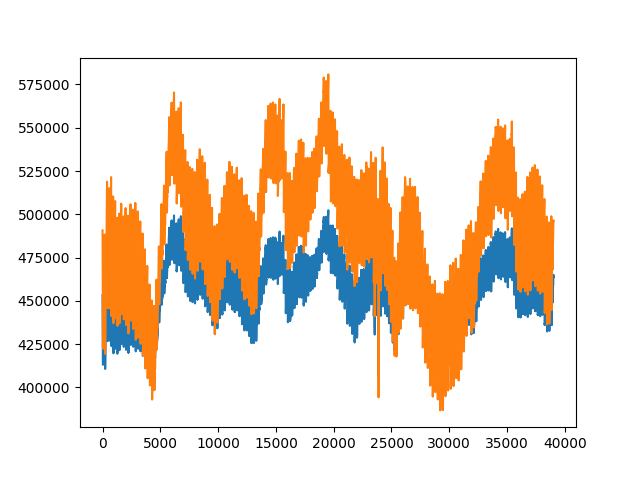

In [17]:
plt.figure()
plt.plot(rd)
plt.plot(ir)

## Data Setup

In [18]:
temp_rd = []
temp_ir = []
plot_indices = [1]
SF_spo2 = 25
BUFFER_SIZE = SF_spo2 * 4

for i in range(len(rd)):
    if (i % 20) == 0:
        temp_rd.append(rd[i])
        temp_ir.append(ir[i])

# Make array sizes divisible by 100 (original size was 1951)
temp_rd = temp_rd[:1900]
temp_ir = temp_ir[:1900]

# Split signal into 100-size chunks
rd_buffs = np.split(np.asarray(temp_rd), 19)
ir_buffs = np.split(np.asarray(temp_ir), 19)

## Peak Detector

In [30]:
def find_peak_above(peak_locs, an_x, size, min_height, max_num_peaks) -> int:
    i = 1
    width = 0
    num_peaks = 0

    while (i < size - 1):
        if (an_x[i] > min_height and an_x[i] > an_x[i - 1]): # find left edge of potential peaks
            width = 1

            while (i + width < size and an_x[i] == an_x[i + width]): # find flat peaks
                width += 1
            
            if (an_x[i] > an_x[i + width] and num_peaks < max_num_peaks): # find right edge of peaks
                peak_locs[num_peaks] = i
                num_peaks += 1
                i += width + 1
            else:
                i += width
        else:
            i += 1
    
    return num_peaks

def sort_peaks_descending(an_x, peak_locs, size):
    peak_locs = np.int_(peak_locs)
    temp = 0

    for i in range(size):
        temp = peak_locs[i]

        j = i
        while (j > 0 and an_x[temp] > an_x[peak_locs[j - 1]]):
            peak_locs[j] = peak_locs[j - 1]
            j -= 1
        
        peak_locs[j] = temp

def remove_close_peaks(peak_locs: np.ndarray, an_x, num_peaks, min_distance) -> int:
    old_num_peaks = 0
    dist = 0
    sort_peaks_descending(an_x, peak_locs, num_peaks) # sort peaks from large to small

    i = -1
    while (i < num_peaks):
        old_num_peaks = num_peaks
        num_peaks = i + 1

        for j in range(i + 1, old_num_peaks):
            dist = peak_locs[j] - (-1 if i == -1 else peak_locs[i])
            if (abs(dist) > min_distance):
                peak_locs[num_peaks] = peak_locs[j]
                num_peaks += 1
        
        i += 1
    
    peak_locs.sort() # re-sort in ascending order
    return num_peaks

def find_peaks(peak_locs, an_x, size, min_height, min_distance, max_num_peaks) -> int:
    num_peaks = find_peak_above(peak_locs, an_x, size, min_height, max_num_peaks)
    num_peaks = remove_close_peaks(peak_locs, an_x, num_peaks, min_distance)
    return num_peaks

## SpO2 Calculation Algorithm

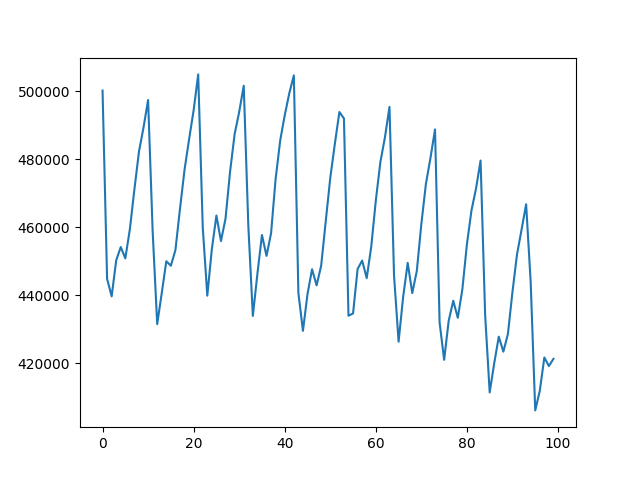

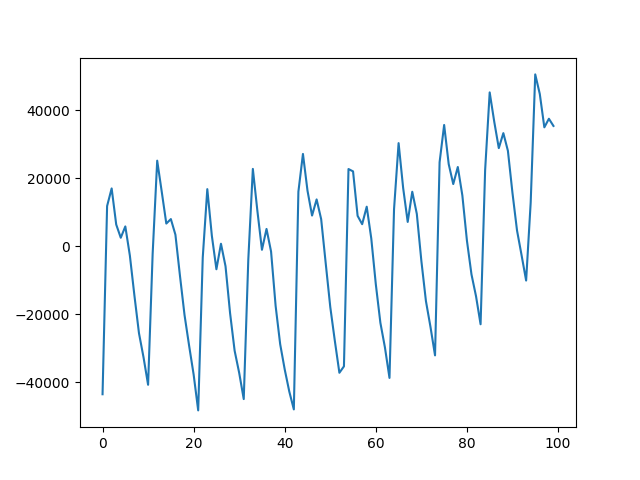

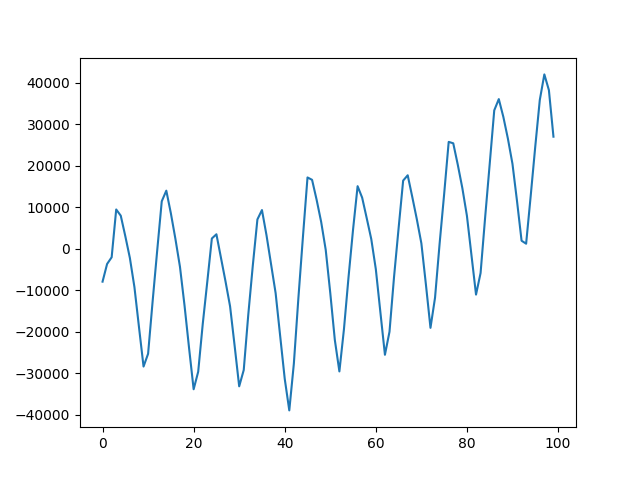

In [31]:
for i in range(len(ir_buffs)):
    rd_buff = rd_buffs[i]
    ir_buff = ir_buffs[i]

    # Plot of original signal
    if i in plot_indices:
        plt.figure()
        plt.plot(ir_buff)

    # Remove DC and invert signal so that we can use peak detector as valley detector
    ir_mean = np.sum(ir_buff) / len(ir_buff)
    an_x = -1 * (ir_buff - ir_mean)

    # Plot of signal after removing DC component and inverting
    if i in plot_indices:
        plt.figure()
        plt.plot(an_x)

    # Apply 4-point moving average
    window = np.ones(4) / 4
    an_x = np.convolve(an_x, window, mode='same')

    # Plot of signal after applying 4-point moving average
    if i in plot_indices:
        plt.figure()
        plt.plot(an_x)
    
    # Calculate minimum acceptable peak height
    min_peak_height = np.sum(an_x) / BUFFER_SIZE
    min_peak_height = max(30, min(min_peak_height, 60)) # Clamp between 30 and 60

    # Find valleys in IR data (15 max)
    ir_valley_locs = np.zeros(15)
    num_peaks = find_peaks(ir_valley_locs, an_x, BUFFER_SIZE, min_peak_height, 4, 15)